In [3]:
!pip install -q xgboost imbalanced-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [5]:
df = pd.read_csv("creditcard.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [6]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [8]:
print("Missing values in Class:", df["Class"].isnull().sum())

Missing values in Class: 0


In [9]:
df = df.dropna(subset=["Class"])

In [10]:
print("Missing values in Class:", df["Class"].isnull().sum())

Missing values in Class: 0


In [11]:
print("Class distribution:")
print(df["Class"].value_counts())

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


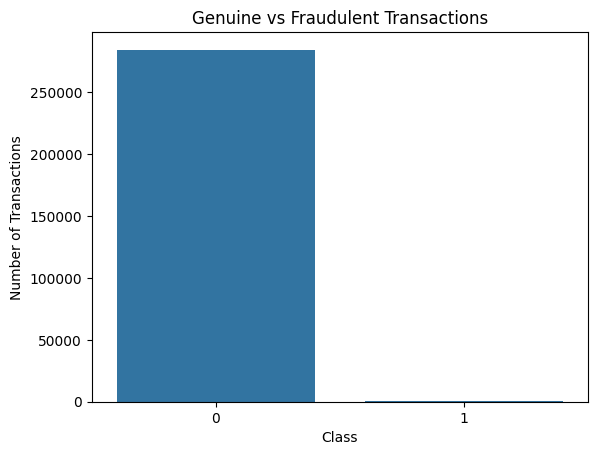

In [12]:
sns.countplot(x="Class", data=df)

plt.title("Genuine vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [13]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [14]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [15]:
if X.isnull().sum().sum() > 0:
    valid_rows = X.notnull().all(axis=1)

    X = X[valid_rows]
    y = y[valid_rows]

In [16]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [18]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


In [19]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [20]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [21]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[1.9445311e-05 1.9620260e-05 2.5958591e-06 6.4495259e-07 5.2550243e-04
 2.8911383e-05 3.6543126e-06 7.9084339e-06 2.8133260e-05 7.6052006e-06]


In [23]:
thresholds_to_test = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
]

for threshold in thresholds_to_test:

    y_pred_temp = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_temp,
        zero_division=0
    )

    print(
        f"Threshold = {threshold:.1f} | "
        f"Precision = {precision:.3f} | "
        f"Recall = {recall:.3f} | "
        f"F1 = {f1:.3f}"
    )

Threshold = 0.1 | Precision = 0.475 | Recall = 0.878 | F1 = 0.616
Threshold = 0.2 | Precision = 0.601 | Recall = 0.878 | F1 = 0.714
Threshold = 0.3 | Precision = 0.654 | Recall = 0.867 | F1 = 0.746
Threshold = 0.4 | Precision = 0.714 | Recall = 0.867 | F1 = 0.783
Threshold = 0.5 | Precision = 0.759 | Recall = 0.867 | F1 = 0.810
Threshold = 0.6 | Precision = 0.792 | Recall = 0.857 | F1 = 0.824
Threshold = 0.7 | Precision = 0.824 | Recall = 0.857 | F1 = 0.840
Threshold = 0.8 | Precision = 0.857 | Recall = 0.857 | F1 = 0.857
Threshold = 0.9 | Precision = 0.884 | Recall = 0.857 | F1 = 0.870


In [24]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

f1_scores = (
    2 * precision * recall /
    (precision + recall + 1e-10)
)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.95314306
Best F1 Score: 0.8888888888389574


In [25]:
y_pred = (y_prob >= best_threshold).astype(int)

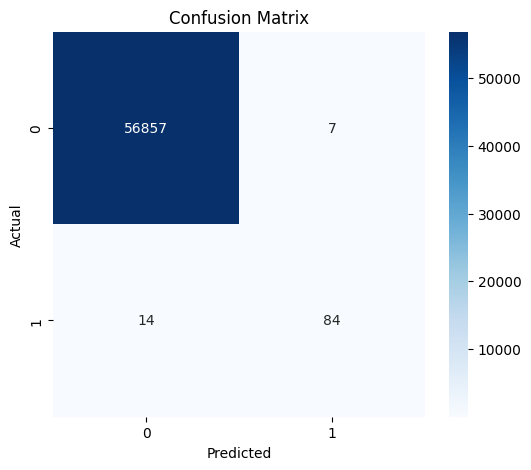

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.981410623126572


In [28]:
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.8734719835300874


In [29]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print("Top 10 Important Features:")
print(importance.head(10))

Top 10 Important Features:
V14    0.621172
V10    0.068540
V4     0.062464
V12    0.034385
V17    0.017767
V8     0.015934
V3     0.015212
V1     0.014547
V13    0.011485
V9     0.009911
dtype: float32


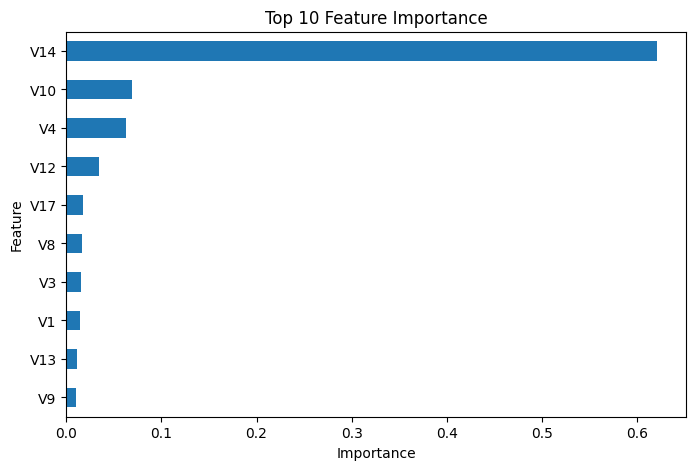

In [30]:
plt.figure(figsize=(8, 5))

importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()